🚀 BẮT ĐẦU CHẠY PIPELINE DỮ LIỆU...
1. Đang tải và ép cân dữ liệu Calendar...
2. Đang tải dữ liệu Sales...
3. Đang Melt (kéo giãn) dữ liệu Sales...
4. Đang Merge Sales với Calendar...

-> Đang xử lý Outliers (IQR) và Zeroes...
5. Ép cân lần cuối cho DataFrame tổng...
-> Đang load dữ liệu Giá (sell_prices.csv)...
-> Đang hợp nhất và tính toán độ co giãn giá...
-> Đang xử lý Sự kiện lễ tết (Calendar Events)...
-> Đang tạo Đặc trưng Thời gian (Time Features)...

✅ Pipeline Dữ liệu hoàn tất! Sẵn sàng cho Machine Learning.

🎯 Đang phân tích sản phẩm: 1437 tại 0

🧠 Đang khởi động hệ thống ML Routing...
-> Phân loại: Intermittent (Ngắt quãng) | Điều hướng: LightGBM Tweedie.
Đang huấn luyện AI...

🔮 Đang chạy thuật toán Dự báo Cuốn chiếu trên 28 ngày của tập Test...

Đang chạy hàng ngàn kịch bản Mô phỏng (Monte Carlo)...

📊 BÁO CÁO SAI SỐ MÔ HÌNH (AI VS ACTUALS - 28 DAYS) 📊
Lỗi Trung bình Tuyệt đối (MAE): 1.02
Lỗi Bình phương Trung bình (RMSE): 1.40

📦 BÁO CÁO HÀNH ĐỘNG (SMART INVENTORY REPORT)

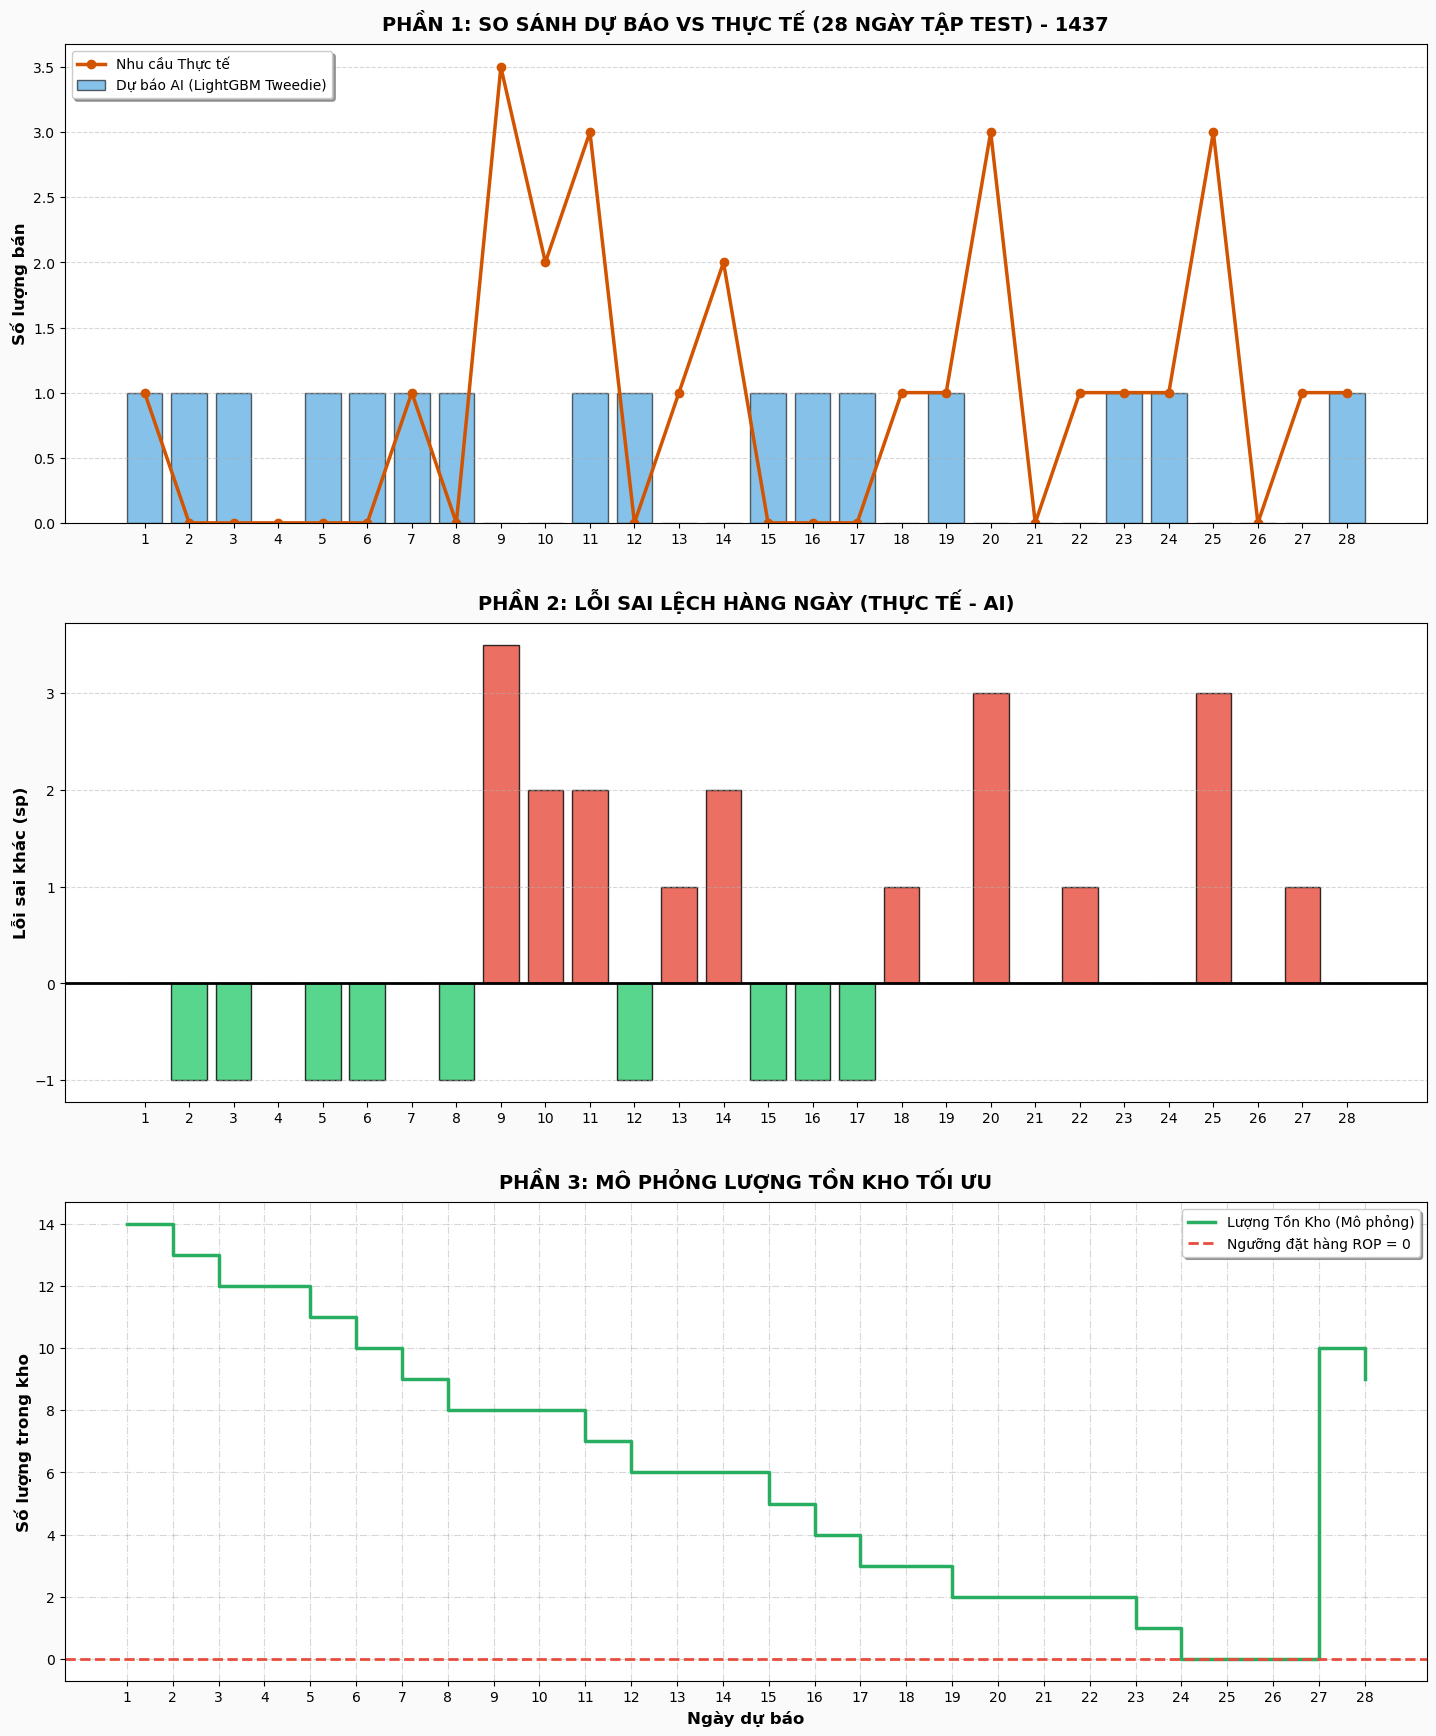

In [3]:
import sys
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Trỏ đường dẫn để gọi các hàm đã đóng gói trong thư mục src
sys.path.append(os.path.abspath('../src'))
from dataPreprocessing import load_and_preprocess_raw
from featureEngineering import generate_all_features, create_lag_features_for_item

RAW_DIR = '../dataset/raw/'

# ==========================================
# BƯỚC 1 & 2: TIỀN XỬ LÝ & TRÍCH XUẤT ĐẶC TRƯNG
# ==========================================
print("🚀 BẮT ĐẦU CHẠY PIPELINE DỮ LIỆU...")
# Lấy 10,000 dòng để chạy nhanh (Báo cáo thực tế bỏ nrows đi nhé)
df_master = load_and_preprocess_raw(RAW_DIR, nrows=10000)
df_featured = generate_all_features(df_master, RAW_DIR)
print("\n✅ Pipeline Dữ liệu hoàn tất! Sẵn sàng cho Machine Learning.\n")

# ==========================================
# BƯỚC 4: CHUẨN BỊ DỮ LIỆU CHO 1 SẢN PHẨM
# ==========================================
# Lọc 1 sản phẩm bán chạy để demo
sample_item = df_featured['item_id'].iloc[0]
sample_store = df_featured['store_id'].iloc[0]
print(f"🎯 Đang phân tích sản phẩm: {sample_item} tại {sample_store}")

df_item = df_featured[(df_featured['item_id'] == sample_item) & (df_featured['store_id'] == sample_store)].copy()
df_item = create_lag_features_for_item(df_item)

features = [
    'day', 'is_weekend', 'sell_price', 'price_discount', 'price_momentum',
    'event_name_1', 'lag_7', 'lag_14', 'rolling_mean_7'
]
target = 'demand'

# ==========================================
# [THAY ĐỔI CỐT LÕI] CHIA TẬP TRAIN/TEST ĐỂ BACKTEST
# Reserve 28 ngày cuối cùng làm Actuals
# ==========================================
train_data_history = df_item.iloc[:-28] # Quá khứ xa
test_data_actuals = df_item.iloc[-28:] # Quá khứ gần (để so sánh)

X_train, y_train = train_data_history[features], train_data_history[target]

# ==========================================
# BƯỚC 5: ĐIỀU HƯỚNG MÔ HÌNH (ML ROUTING) & HUẤN LUYỆN
# ==========================================
print("\n🧠 Đang khởi động hệ thống ML Routing...")
item_category = 'Intermittent (Ngắt quãng)' # Giả định

params = {'metric': 'rmse', 'learning_rate': 0.05, 'num_leaves': 31, 'verbose': -1, 'force_col_wise': True}

if 'Smooth' in item_category or 'Erratic' in item_category:
    print(f"-> Phân loại: {item_category} | Điều hướng: LightGBM Regression.")
    params['objective'] = 'regression'
else:
    print(f"-> Phân loại: {item_category} | Điều hướng: LightGBM Tweedie.")
    params['objective'] = 'tweedie'
    params['tweedie_variance_power'] = 1.1

categorical_features = ['event_name_1']
train_set = lgb.Dataset(X_train, y_train, categorical_feature=categorical_features)

print("Đang huấn luyện AI...")
model = lgb.train(params, train_set, num_boost_round=100) 

# ==========================================
# BƯỚC 5B: RECURSIVE FORECASTING (DỰ BÁO CUỐN CHIẾU CHO TẬP TEST)
# ==========================================
print("\n🔮 Đang chạy thuật toán Dự báo Cuốn chiếu trên 28 ngày của tập Test...")

future_horizon = 28
# Bắt đầu cuốn chiếu từ ngày cuối cùng của tập Train
history_df = train_data_history.copy()
future_predictions = []

for i in range(1, future_horizon + 1):
    last_row = history_df.iloc[-1]
    next_date = last_row['date'] + pd.Timedelta(days=1)
    current_demands = history_df['demand'].values
    
    new_features = pd.DataFrame([{
        'day': next_date.day,
        'is_weekend': 1 if next_date.dayofweek in [5, 6] else 0,
        'sell_price': last_row['sell_price'],          
        'price_discount': last_row['price_discount'],  
        'price_momentum': 1.0,                         
        'event_name_1': last_row['event_name_1'],      
        'lag_7': current_demands[-7],
        'lag_14': current_demands[-14],
        'rolling_mean_7': np.mean(current_demands[-7:])
    }])
    
    pred_demand = max(0, model.predict(new_features)[0]) 
    future_predictions.append(pred_demand)
    
    new_row = pd.DataFrame({'date': [next_date], 'demand': [pred_demand], 'sell_price': last_row['sell_price'], 'price_discount': last_row['price_discount'], 'event_name_1': last_row['event_name_1']})
    history_df = pd.concat([history_df, new_row], ignore_index=True)

daily_demand_forecast_ai = np.round(future_predictions).astype(int)
daily_demand_actuals = test_data_actuals['demand'].values

# ==========================================
# BƯỚC 6 & 7: MÔ PHỎNG TỒN KHO & TÌM EOQ, ROP TỐI ƯU
# ==========================================
print("\nĐang chạy hàng ngàn kịch bản Mô phỏng (Monte Carlo)...")

LEAD_TIME = 3            
ORDERING_COST = 50.0     
HOLDING_COST = 0.5       
STOCKOUT_COST = 5.0      
INITIAL_INVENTORY = 15   

def simulate_inventory(demand_array, ROP, Q):
    inventory = INITIAL_INVENTORY
    total_cost = 0
    days_to_arrival = 0
    order_placed = False
    inventory_history = []
    for demand in demand_array:
        if order_placed and days_to_arrival == 0:
            inventory += Q
            order_placed = False
        if inventory >= demand:
            inventory -= demand
        else:
            total_cost += (demand - inventory) * STOCKOUT_COST
            inventory = 0
        total_cost += inventory * HOLDING_COST
        if inventory <= ROP and not order_placed:
            total_cost += ORDERING_COST
            order_placed = True
            days_to_arrival = LEAD_TIME
        if order_placed:
            days_to_arrival -= 1
        inventory_history.append(inventory)
    return total_cost, inventory_history

best_cost, best_ROP, best_Q = float('inf'), 0, 0
best_history = []

for rop in range(0, 50, 2):
    for q in range(10, 150, 5):
        cost, history = simulate_inventory(daily_demand_forecast_ai, rop, q)
        if cost < best_cost:
            best_cost, best_ROP, best_Q, best_history = cost, rop, q, history

# ==========================================
# BÁO CÁO ĐẦU RA KÈM CHỈ SỐ SAI SỐ (BACKTEST)
# ==========================================
print("\n" + "="*60)
print("📊 BÁO CÁO SAI SỐ MÔ HÌNH (AI VS ACTUALS - 28 DAYS) 📊")
print("="*60)

mae = mean_absolute_error(daily_demand_actuals, daily_demand_forecast_ai)
rmse = np.sqrt(mean_squared_error(daily_demand_actuals, daily_demand_forecast_ai))

print(f"Lỗi Trung bình Tuyệt đối (MAE): {mae:,.2f}")
print(f"Lỗi Bình phương Trung bình (RMSE): {rmse:,.2f}")

daily_errors = daily_demand_actuals - daily_demand_forecast_ai

print("\n" + "="*60)
print("📦 BÁO CÁO HÀNH ĐỘNG (SMART INVENTORY REPORT) 📦")
print("="*60)
print(f"🎯 Điểm đặt hàng ROP: {best_ROP} sp | 📦 Lượng đặt EOQ: {best_Q} sp")
print(f"💰 Tổng chi phí dự kiến: ${best_cost:,.2f}")
print("="*60)

# ==========================================
# VẼ BIỂU ĐỒ KÉP 3 TẦNG VÀ LƯU ẢNH TỰ ĐỘNG
# ==========================================
# 3 rows, 1 column
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 18), facecolor='#FAFAFA')

# --- Biểu đồ 1: So sánh AI vs Thực tế (Combo Chart) ---
ax1.bar(range(1, 29), daily_demand_forecast_ai, color='#3498DB', edgecolor='black', alpha=0.6, label='Dự báo AI (LightGBM Tweedie)')
ax1.plot(range(1, 29), daily_demand_actuals, color='#D35400', marker='o', linewidth=2.5, label='Nhu cầu Thực tế')
ax1.set_title(f"PHẦN 1: SO SÁNH DỰ BÁO VS THỰC TẾ (28 NGÀY TẬP TEST) - {sample_item}", fontsize=14, fontweight='bold', pad=10)
ax1.set_ylabel("Số lượng bán", fontsize=12, fontweight='bold')
ax1.set_xticks(range(1, 29))
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', shadow=True)

# --- Biểu đồ 2: Biểu đồ Lỗi Sai lệch hàng ngày (Daily Error Chart) ---
colors = ['#E74C3C' if e > 0 else '#2ECC71' for e in daily_errors] # Red for Under-forecast, Green for Over
ax2.bar(range(1, 29), daily_errors, color=colors, edgecolor='black', alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax2.set_title(f"PHẦN 2: LỖI SAI LỆCH HÀNG NGÀY (THỰC TẾ - AI)", fontsize=14, fontweight='bold', pad=10)
ax2.set_ylabel("Lỗi sai khác (sp)", fontsize=12, fontweight='bold')
ax2.set_xticks(range(1, 29))
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# --- Biểu đồ 3: Mô phỏng Tồn kho theo AI (Giữ nguyên form cũ) ---
ax3.step(range(1, 29), best_history, where='post', color='#27AE60', linewidth=2.5, label='Lượng Tồn Kho (Mô phỏng)')
ax3.axhline(y=best_ROP, color='#E74C3C', linestyle='--', linewidth=2, label=f'Ngưỡng đặt hàng ROP = {best_ROP}')
ax3.set_title(f"PHẦN 3: MÔ PHỎNG LƯỢNG TỒN KHO TỐI ƯU", fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel("Ngày dự báo", fontsize=12, fontweight='bold')
ax3.set_ylabel("Số lượng trong kho", fontsize=12, fontweight='bold')
ax3.set_xticks(range(1, 29))
ax3.grid(True, linestyle='-.', alpha=0.5)
ax3.legend(loc='upper right', frameon=True, shadow=True)

plt.tight_layout(pad=3.0) 
os.makedirs('../docs/images', exist_ok=True)
plt.savefig('../docs/images/bieu_do_validation_tong_hop.png', dpi=300, bbox_inches='tight')
print("\n📸 Đã lưu ảnh biểu đồ tổng hợp validation tại: ../docs/images/bieu_do_validation_tong_hop.png")

plt.show()